# Number of Training Samples

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

from collections import defaultdict
from scipy import stats

In [76]:
experiment = "num_train_samples_study"

baseline_models = [
    "multiclass",
    "ensemble",
]

In [77]:
# # AIT configuration
# dataset = "aitv2"
# scenario = "santos"
# plots_title = f"AIT-LDS V2 Santos"

# logic_files = [
#     "ait_temp", 
#     "ait_temp_context",
# ]

In [89]:
# DARPA configuration
dataset = "darpa2000"
scenario = "s1_inside"

plots_title = f"Darpa 2000 S1 Inside"

logic_files = [
    "darpa_temp", 
    "darpa_temp_context",
]

## Collect Metrics

In [79]:
plots_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")
plots_dir.mkdir(parents=True, exist_ok=True)

In [80]:
experiments = {}

In [81]:
def confidence_interval(data, confidence=0.95):
    """Returns (lower_err, upper_err) for use with errorbar."""
    n = len(data)
    if n < 2:
        return (0, 0)
    sem = stats.sem(data)
    h = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return (h, h)  # symmetric for errorbar

In [82]:
# DPL Models
for logic_file in logic_files:
    metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/metrics")
    file_paths = list(metrics_dir.iterdir())

    # Nested dict: subset_size -> list of metrics dicts (one per run)
    metrics_by_subset = defaultdict(lambda: {"mf1": [], "fpr": [], "dr": []})
    
    for file_path in file_paths:

        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        if "context" in logic_file:
            if logic_file not in experiment_name:
                continue
        else: 
            # print(experiment_name_parts[2])
            if experiment_name_parts[2] == "context":
                continue

        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()
        subset = experiment_name_parts[-4]
        subset_size = int(subset.split("b")[0])

        metrics_by_subset[subset_size]["mf1"].append(metrics["macro_f1"])
        metrics_by_subset[subset_size]["fpr"].append(metrics["false_alarm_rate"])
        metrics_by_subset[subset_size]["dr"].append(metrics["detection_rate"])

    # Aggregate: compute mean and CI for each subset_size
    subset_sizes = sorted(metrics_by_subset.keys())

    logic_file_parts = logic_file.split("_")
    logic_name = "_".join(logic_file_parts[1:])  # e.g., "temp" or "temp_context"
    model_name = f"dpl_{logic_name}"
    
    experiments[model_name] = {
        "subset_sizes": subset_sizes,
        "mf1_scores": [np.mean(metrics_by_subset[s]["mf1"]) for s in subset_sizes],
        "mf1_ci": [confidence_interval(metrics_by_subset[s]["mf1"]) for s in subset_sizes],
        "false_alarm_rates": [np.mean(metrics_by_subset[s]["fpr"]) for s in subset_sizes],
        "fpr_ci": [confidence_interval(metrics_by_subset[s]["fpr"]) for s in subset_sizes],
        "detection_rates": [np.mean(metrics_by_subset[s]["dr"]) for s in subset_sizes],
        "dr_ci": [confidence_interval(metrics_by_subset[s]["dr"]) for s in subset_sizes],
    }


In [83]:
print(experiments.keys())

dict_keys(['dpl_temp', 'dpl_temp_context'])


In [94]:
# Baseline Models
for model in baseline_models:
    metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/baselines/metrics")
    file_paths = list(metrics_dir.iterdir())

    metrics_by_subset = defaultdict(lambda: {"mf1": [], "fpr": [], "dr": []})

    for file_path in file_paths:

        experiment_name = str(file_path.stem)
        if model not in experiment_name:
            continue
        
        with open(file_path) as f:
            metrics = json.load(f)
        
        experiment_name_parts = experiment_name.split("_")
        subset = experiment_name_parts[-4]
        subset_size = int(subset.split("b")[0])

        metrics_by_subset[subset_size]["mf1"].append(metrics["macro_f1"])
        metrics_by_subset[subset_size]["fpr"].append(metrics["false_alarm_rate"])
        metrics_by_subset[subset_size]["dr"].append(metrics["detection_rate"])
    
    subset_sizes = sorted(metrics_by_subset.keys())
    
    model_name = f"lstm_{model}"
    experiments[model_name] = {
        "subset_sizes": subset_sizes,
        "mf1_scores": [np.mean(metrics_by_subset[s]["mf1"]) for s in subset_sizes],
        "mf1_ci": [confidence_interval(metrics_by_subset[s]["mf1"]) for s in subset_sizes],
        "false_alarm_rates": [np.mean(metrics_by_subset[s]["fpr"]) for s in subset_sizes],
        "fpr_ci": [confidence_interval(metrics_by_subset[s]["fpr"]) for s in subset_sizes],
        "detection_rates": [np.mean(metrics_by_subset[s]["dr"]) for s in subset_sizes],
        "dr_ci": [confidence_interval(metrics_by_subset[s]["dr"]) for s in subset_sizes],
    }


In [95]:
print(experiments.keys())

dict_keys(['dpl_temp', 'dpl_temp_context', 'lstm_multiclass', 'lstm_ensemble'])


## Plot Metrics

In [96]:
def num_samples_plot(experiments, metric, plots_dir, plots_title, save_fig=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    all_subset_sizes = sorted({x for data in experiments.values() for x in data["subset_sizes"]})
    colors = plt.cm.tab10.colors

    ci_key = {
        "mf1_scores": "mf1_ci",
        "false_alarm_rates": "fpr_ci",
        "detection_rates": "dr_ci",
    }[metric]

    for i, (logic_file, data) in enumerate(experiments.items()):
        means = np.array(data[metric])
        cis = np.array(data[ci_key])  # shape (n, 2)
        sizes = np.array(data["subset_sizes"])

        ax.plot(sizes, means, marker='o', markersize=8, linewidth=2.5,
                color=colors[i % len(colors)], label=logic_file)
        ax.fill_between(sizes, means - cis[:, 0], means + cis[:, 1],
                        color=colors[i % len(colors)], alpha=0.2)

    ax.set_xscale('log')
    ax.set_xticks(all_subset_sizes)
    ax.set_xticklabels([f'{x:,}' for x in all_subset_sizes])
    ax.set_xlabel('Number of Training Samples', fontsize=12, fontweight='medium')
    y_label_mapping = {
        "mf1_scores": "Macro F1 Score",
        "false_alarm_rates": "False Alarm Rate",
        "detection_rates": "Detection Rate",
    }
    ax.set_ylabel(y_label_mapping.get(metric, metric.replace("_", " ")), fontsize=12, fontweight='medium')
    ax.set_title(plots_title, fontsize=14, pad=15)
    ax.legend(frameon=True, fancybox=True, shadow=False, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()

    if save_fig:
        plots_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(plots_dir / f"num_train_samples_{metric}.png", dpi=150, bbox_inches='tight')
    plt.show()


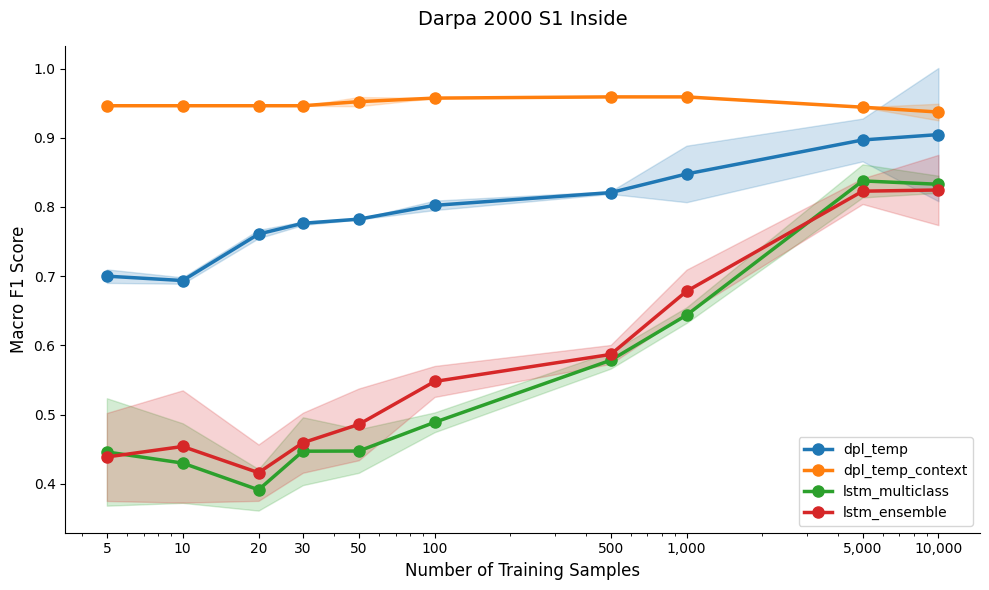

In [97]:
metric = "mf1_scores"
num_samples_plot(experiments, metric, plots_dir, plots_title)

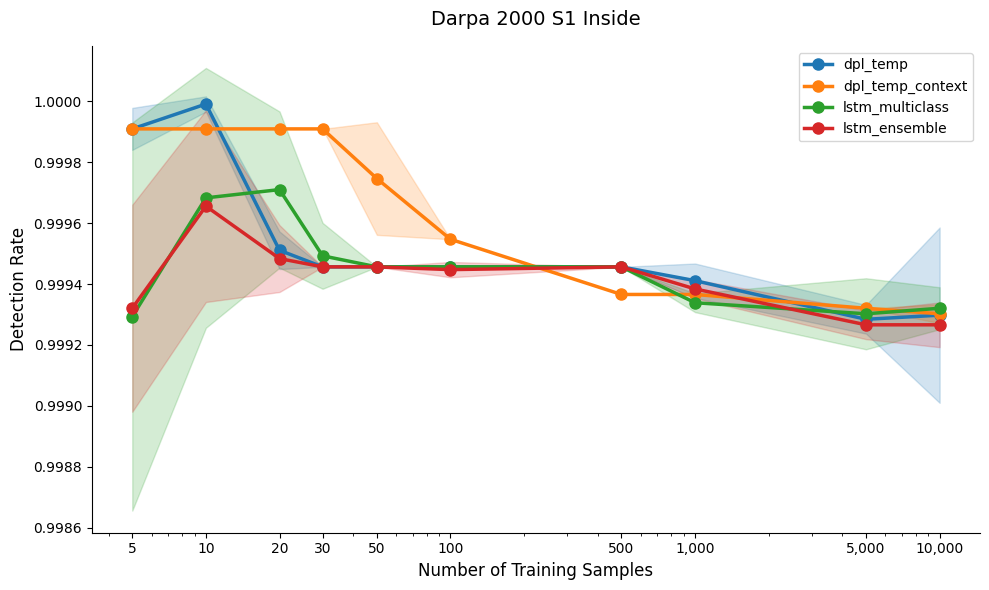

In [98]:
metric = "detection_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)

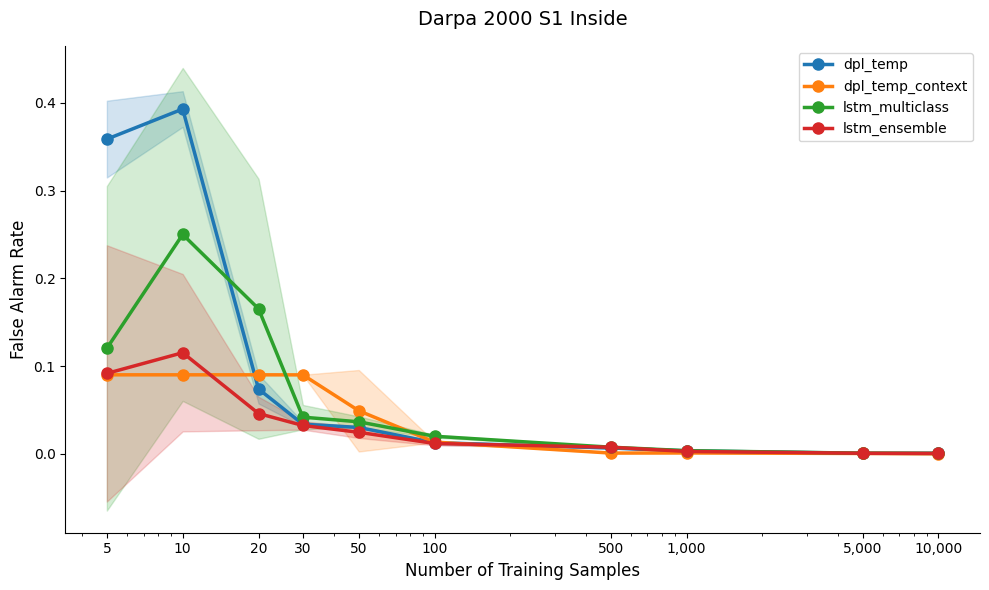

In [99]:
metric = "false_alarm_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)